# Assignment 13 – Ecommerce Sales Analysis

**Objective:** Analyze sales trends across products, categories, and regions; identify top-selling products and seasonal patterns; and provide insights for business decisions.

This notebook follows the supplied Assignment 13 / Ecommerce Sales Analysis project brief and uses `ecommerce_dataset.xlsx`.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


## 2. Load the Dataset Using Pandas

In [2]:
df = pd.read_excel("ecommerce_dataset.xlsx")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (506, 14)


,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,2023-01-01 00:00:00,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,2023-02-01 00:00:00,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,2023-03-01 00:00:00,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,2023-04-01 00:00:00,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,2023-05-01 00:00:00,23165.07,January,0.0,1.0,NaN,1.0,0.0


## 3. Check Data Types

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             506 non-null    int64  
 1   product              506 non-null    object 
 2   category             506 non-null    object 
 3   price                506 non-null    float64
 4   quantity             506 non-null    int64  
 5   payment_method       506 non-null    object 
 6   date                 506 non-null    object 
 7   total                506 non-null    float64
 8   Month                506 non-null    object 
 9   Discount             506 non-null    float64
 10  City Code            491 non-null    float64
 11  Order Priority Code  487 non-null    float64
 12  Latitude             506 non-null    float64
 13  Longtitude           506 non-null    float64
dtypes: float64(7), int64(2), object(5)
memory usage: 55.5+ KB


## 4. Drop Irrelevant Columns

The project brief asks to remove `Latitude` and `Longitude`. In the supplied Excel file, the longitude column is spelled **`Longtitude`**, so that actual column name is removed.


In [4]:
columns_to_drop = [c for c in ["Latitude", "Longitude", "Longtitude"] if c in df.columns]
df = df.drop(columns=columns_to_drop)
print("Dropped columns:", columns_to_drop)
df.head()


Dropped columns: ['Latitude', 'Longtitude']


,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code
0,1,Watch,Electronics,12652.30,4,Easypaisa,2023-01-01 00:00:00,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,2023-02-01 00:00:00,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,2023-03-01 00:00:00,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,2023-04-01 00:00:00,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,2023-05-01 00:00:00,23165.07,January,0.0,1.0,NaN


## 5. Rename City Code and Order Priority Code

In [5]:
df = df.rename(columns={
    "City Code": "City",
    "Order Priority Code": "Order Priority"
})
df.columns.tolist()


['order_id',
 'product',
 'category',
 'price',
 'quantity',
 'payment_method',
 'date',
 'total',
 'Month',
 'Discount',
 'City',
 'Order Priority']

## 6. Check Duplicate Rows

In [6]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)


Duplicate rows: 6


## 7. Drop Duplicate Records

In [7]:
rows_before = len(df)
df = df.drop_duplicates().copy()
rows_after = len(df)

print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Rows removed:", rows_before - rows_after)


Rows before: 506
Rows after : 500
Rows removed: 6


## 8. Check Missing / Null Values

In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values


Order Priority    19
City              15
order_id           0
product            0
price              0
category           0
quantity           0
payment_method     0
total              0
date               0
Discount           0
Month              0
dtype: int64

## 9. Fill Missing Sales Value by Median

The sales/order-value field in this dataset is `total`. The code below follows the assignment requirement. If missing `total` values exist, they are replaced with the median. In the supplied dataset there are no missing `total` values, so no replacement is required.


In [9]:
missing_sales_before = df["total"].isna().sum()
median_sales = df["total"].median()

df["total"] = df["total"].fillna(median_sales)

print("Missing total values before:", missing_sales_before)
print("Median total:", median_sales)
print("Missing total values after:", df["total"].isna().sum())


Missing total values before: 0
Median total: 78100.345
Missing total values after: 0


## 10. Additional Preparation for Analysis

- Convert `date` to a proper datetime field.
- Replace city codes with the city names provided in the project brief.
- Replace order-priority codes with their labels.
- Missing codes are shown as `Unknown` so those rows remain in the analysis.


In [10]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

city_map = {
    1: "Karachi",
    2: "Lahore",
    3: "Islamabad",
    4: "Faisalabad",
    5: "Quetta",
    6: "Peshawar"
}

priority_map = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
    3: "CRITICAL"
}

df["City Name"] = df["City"].map(city_map).fillna("Unknown")
df["Order Priority Name"] = df["Order Priority"].map(priority_map).fillna("Unknown")

df.head()


,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority,City Name,Order Priority Name
0,1,Watch,Electronics,12652.30,4,Easypaisa,2023-01-01,50609.20,January,0.0,1.0,2.0,Karachi,HIGH
1,2,Bag,Fashion,20053.64,2,Credit Card,2023-02-01,40107.28,January,0.1,1.0,2.0,Karachi,HIGH
2,3,Shoes,Fashion,13274.17,2,JazzCash,2023-03-01,26548.34,January,0.1,1.0,2.0,Karachi,HIGH
3,4,Bag,Electronics,15332.08,1,COD,2023-04-01,15332.08,January,0.1,1.0,2.0,Karachi,HIGH
4,5,Bag,Accessories,23165.07,1,Debit Card,2023-05-01,23165.07,January,0.0,1.0,NaN,Karachi,Unknown


# Exploratory Data Analysis

## Q1. Top 5 Best-Selling Products

In [11]:
top5_products = (
    df.groupby("product", as_index=False)["quantity"]
      .sum()
      .sort_values("quantity", ascending=False)
      .head(5)
)

top5_products


,product,quantity
5,Watch,256
3,Mobile,230
1,Headphones,227
0,Bag,189
4,Shoes,188


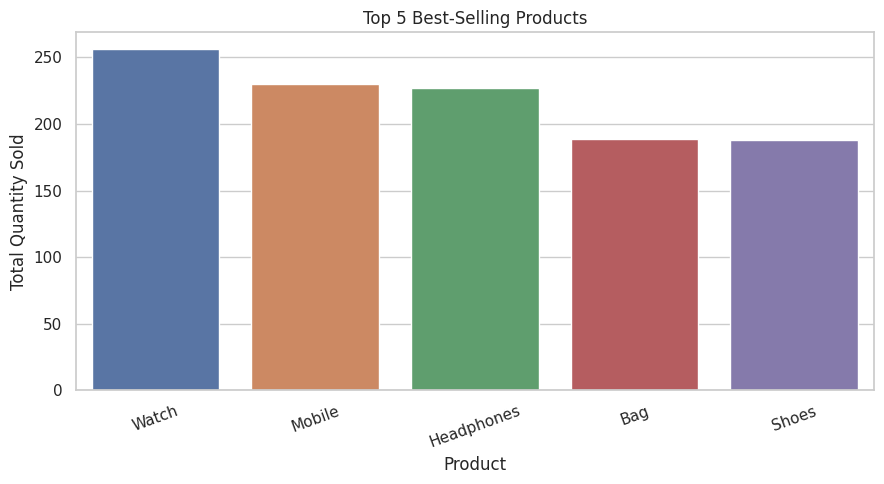

In [12]:
plt.figure(figsize=(9, 5))
sns.barplot(data=top5_products, x="product", y="quantity", hue="product", legend=False)
plt.title("Top 5 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Observation
**Watch** is the best-selling product by quantity, with **256 units** sold. It is followed by **Mobile (230)**, **Headphones (227)**, **Bag (189)**, and **Shoes (188)**. Watches therefore show the strongest unit demand among products in this dataset.


## Q2. Payment Method Distribution

In [13]:
payment_counts = df["payment_method"].value_counts()
payment_counts


payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64

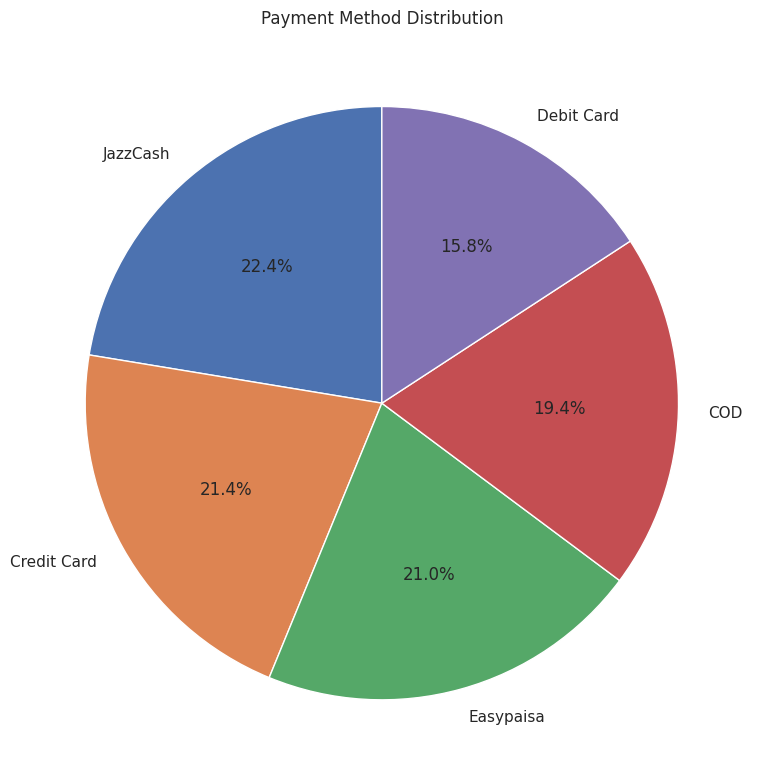

In [14]:
plt.figure(figsize=(8, 8))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Payment Method Distribution")
plt.tight_layout()
plt.show()


### Observation
**JazzCash** is the most frequently used payment method with **112 orders (22.4%)**. Credit Card and Easypaisa are close behind, while Debit Card has the lowest share. Overall, customers use a fairly diverse mix of digital and cash-on-delivery payment methods.


## Q3. Month-wise Sales

In [15]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Month", as_index=False)["total"]
      .sum()
)

monthly_sales["Month"] = pd.Categorical(
    monthly_sales["Month"],
    categories=month_order,
    ordered=True
)
monthly_sales = monthly_sales.sort_values("Month")
monthly_sales


,Month,total
4,January,6238414.59
3,February,5545040.22
7,March,6711119.66
0,April,6275753.74
8,May,5909845.92
6,June,2860920.11
5,July,2688475.62
1,August,2557288.54
11,September,2515916.08
10,October,3139444.82


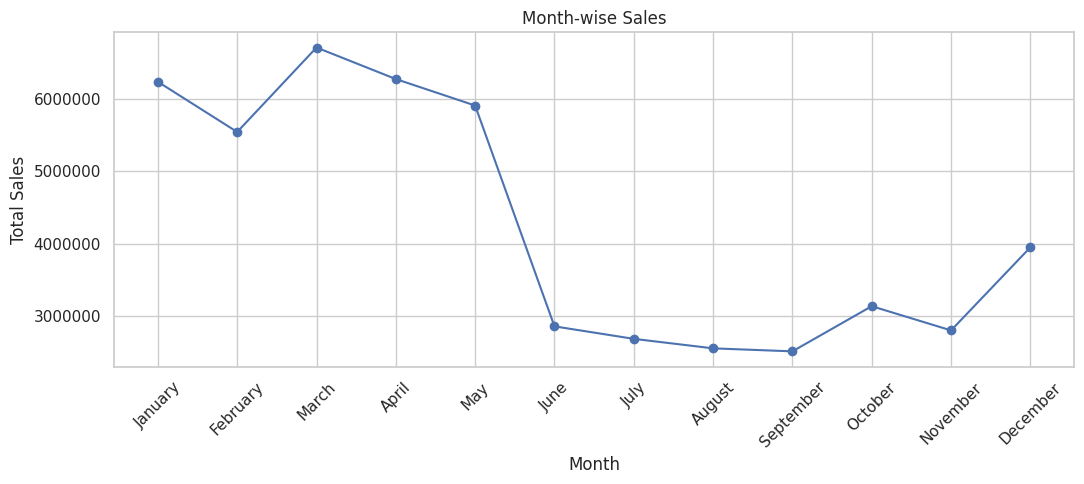

In [16]:
plt.figure(figsize=(11, 5))
plt.plot(monthly_sales["Month"].astype(str), monthly_sales["total"], marker="o")
plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


### Observation
Sales are strongest in the first five months of the year. **March** records the highest sales at approximately **6.71 million**, followed by April and January. Sales fall notably from June onward, with **September** showing the lowest monthly sales at approximately **2.52 million**. This indicates a clear seasonal pattern in the dataset.


## Q4. City-wise Sales

In [17]:
city_sales = (
    df.groupby("City Name", as_index=False)["total"]
      .sum()
      .sort_values("total", ascending=False)
)

city_sales


,City Name,total
3,Lahore,14665005.16
5,Quetta,9488620.43
1,Islamabad,8028811.58
0,Faisalabad,6318998.97
4,Peshawar,6194016.19
2,Karachi,5060916.14
6,Unknown,1443567.95


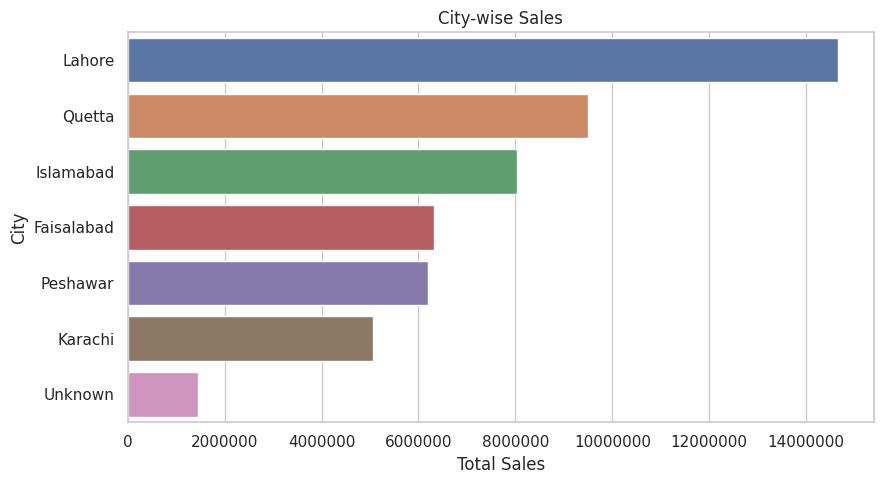

In [18]:
plt.figure(figsize=(9, 5))
sns.barplot(data=city_sales, y="City Name", x="total", hue="City Name", legend=False)
plt.title("City-wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


### Observation
**Lahore** generates the highest sales, approximately **14.67 million**, making it the strongest city market in this dataset. **Quetta** and **Islamabad** rank next. Karachi has the lowest sales among the named cities. Records with missing city codes are retained as **Unknown** rather than being removed.


## Q5. Monthly Sales by Category – Side-by-Side Bar Chart

In [19]:
monthly_category = (
    df.groupby(["Month", "category"], as_index=False)["total"]
      .sum()
)

monthly_category["Month"] = pd.Categorical(
    monthly_category["Month"],
    categories=month_order,
    ordered=True
)

category_pivot = (
    monthly_category
    .pivot(index="Month", columns="category", values="total")
    .reindex(month_order)
    .fillna(0)
)

category_pivot


category,Accessories,Electronics,Fashion
Month,,,
January,2745729.82,1855039.15,1637645.62
February,1178881.69,1929360.80,2436797.73
March,2749630.71,2457415.74,1504073.21
April,2387980.38,2265079.20,1622694.16
May,1240740.21,2352232.89,2316872.82
June,1421673.13,657353.10,781893.88
July,961408.72,1218489.97,508576.93
August,521529.94,881950.11,1153808.49
September,849152.91,952931.97,713831.20


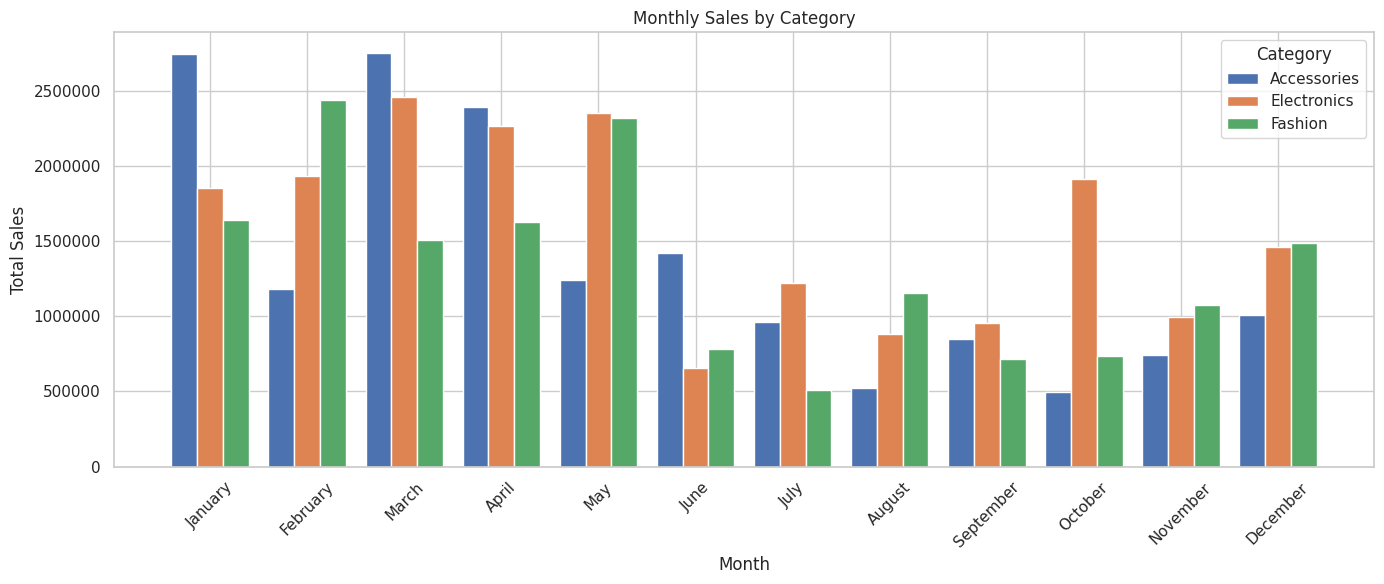

In [20]:
categories = category_pivot.columns.tolist()
x = np.arange(len(category_pivot.index))
width = 0.8 / len(categories)

plt.figure(figsize=(14, 6))

for i, category in enumerate(categories):
    offset = (i - (len(categories) - 1) / 2) * width
    plt.bar(
        x + offset,
        category_pivot[category].values,
        width,
        label=category
    )

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(x, category_pivot.index, rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Category")
plt.tight_layout()
plt.show()


### Observation
Monthly category performance varies across the year rather than being driven by one category in every month. Electronics, Fashion, and Accessories each contribute materially to total sales. The chart also confirms the broader monthly pattern: category sales are generally stronger during the early part of the year and lower during the middle-to-late months.


# Final Summary

1. **Watch** is the top-selling product by quantity.
2. **JazzCash** is the most commonly used payment method.
3. **March** is the highest-sales month, while September is the lowest in the supplied data.
4. **Lahore** contributes the highest city-level sales.
5. Sales show a noticeable seasonal decline after the stronger first part of the year.
6. All three product categories contribute to monthly sales, with their relative performance changing from month to month.

These findings can support product stocking, city-focused marketing, payment-channel planning, and seasonal sales decisions.
